# Better.com Trustpilot Review Analysis

This notebook analyzes Better.com customer reviews from Trustpilot to examine changes in customer sentiment and ratings before and after the full implementation of Betsy on October 17, 2024.

The analysis includes:
- Data loading
- Data cleaning
- Date processing
- Pre/post Betsy variable construction
- Descriptive statistics
- Rating trends
- Sentiment analysis

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("../Data/NLP/Better_Reviews.csv")
df.head()

,companyPageUrl,reviewId,companyName,businessUnitId,reviewUrl,reviewDate,reviewDateOfExperience,reviewLabel,isReviewVerified,reviewer,reviewerId,reviewTitle,reviewDescription,reviewRatingScore,reviewersCountry,reviewLanguage,reviewCompanyResponse,scrapedDateTime,scrapedAtReviewPageNumber
0,https://www.trustpilot.com/review/better.com?l...,69ec1710f8734dbf2d13d1aa,Better,577c1c600000ff000591fa04,https://www.trustpilot.com/reviews/69ec1710f87...,2026-04-25T03:21:20.000Z,2026-03-02T00:00:00.000Z,invited,True,Chorina,6986a721e90c6e3808315b6f,The whole team was exceptionally…,The whole team was exceptionally helpful and w...,5,US,en,NaN,2026-04-26T15:03:52.712Z,1
1,https://www.trustpilot.com/review/better.com?l...,69eacc45947a9857d233c5a3,Better,577c1c600000ff000591fa04,https://www.trustpilot.com/reviews/69eacc45947...,2026-04-24T03:49:57.000Z,2026-03-09T00:00:00.000Z,invited,True,Erwin Kurt Cullamar,69eacc4479190515fc0e9b94,Loan originator and loan coordinator…,Loan originator and loan coordinator made the ...,5,US,en,NaN,2026-04-26T15:03:52.713Z,1
2,https://www.trustpilot.com/review/better.com?l...,69eac948895e1864359c1b0e,Better,577c1c600000ff000591fa04,https://www.trustpilot.com/reviews/69eac948895...,2026-04-24T03:37:13.000Z,2026-04-08T00:00:00.000Z,invited,True,Mitch,68bef2fb27764aa2e25eb827,John and Sonia made my experience…,John and Sonia made my experience outstanding....,5,US,en,NaN,2026-04-26T15:03:52.713Z,1
3,https://www.trustpilot.com/review/better.com?l...,69e800cc2103495ba71fbf80,Better,577c1c600000ff000591fa04,https://www.trustpilot.com/reviews/69e800cc210...,2026-04-22T00:57:16.000Z,2026-03-15T00:00:00.000Z,invited,True,George D Gilmartin,69e800cb98a7924e9e2c55d5,"Irene Lee (my loan officer) was…professional, ...","Irene Lee (my loan officer) was professional, ...",5,US,en,Hello George! Thank you for your thoughtful fe...,2026-04-26T15:03:52.713Z,1
4,https://www.trustpilot.com/review/better.com?l...,69e7539c12572682026d8adb,Better,577c1c600000ff000591fa04,https://www.trustpilot.com/reviews/69e7539c125...,2026-04-21T12:38:21.000Z,2026-04-21T00:00:00.000Z,not-verified,False,Amy,5f92db1080251b001cc5d3ac,Richard came to my nursery today to…,Richard came to my nursery today to help with ...,5,GB,en,NaN,2026-04-26T15:03:52.713Z,1


In [33]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934 entries, 0 to 1933
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   companyPageUrl             1934 non-null   object
 1   reviewId                   1934 non-null   object
 2   companyName                1934 non-null   object
 3   businessUnitId             1934 non-null   object
 4   reviewUrl                  1934 non-null   object
 5   reviewDate                 1934 non-null   object
 6   reviewDateOfExperience     1934 non-null   object
 7   reviewLabel                1934 non-null   object
 8   isReviewVerified           1934 non-null   bool  
 9   reviewer                   1934 non-null   object
 10  reviewerId                 1934 non-null   object
 11  reviewTitle                1934 non-null   object
 12  reviewDescription          1934 non-null   object
 13  reviewRatingScore          1934 non-null   int64 
 14  reviewer

Index(['companyPageUrl', 'reviewId', 'companyName', 'businessUnitId',
       'reviewUrl', 'reviewDate', 'reviewDateOfExperience', 'reviewLabel',
       'isReviewVerified', 'reviewer', 'reviewerId', 'reviewTitle',
       'reviewDescription', 'reviewRatingScore', 'reviewersCountry',
       'reviewLanguage', 'reviewCompanyResponse', 'scrapedDateTime',
       'scrapedAtReviewPageNumber'],
      dtype='object')

In [37]:
df_clean = df[[
    "reviewId",
    "reviewDate",
    "reviewDescription",
    "reviewRatingScore",
    "reviewersCountry",
    "reviewLanguage",
    "isReviewVerified"
]].copy()
df_clean.head()

,reviewId,reviewDate,reviewDescription,reviewRatingScore,reviewersCountry,reviewLanguage,isReviewVerified
0,69ec1710f8734dbf2d13d1aa,2026-04-25T03:21:20.000Z,The whole team was exceptionally helpful and w...,5,US,en,True
1,69eacc45947a9857d233c5a3,2026-04-24T03:49:57.000Z,Loan originator and loan coordinator made the ...,5,US,en,True
2,69eac948895e1864359c1b0e,2026-04-24T03:37:13.000Z,John and Sonia made my experience outstanding....,5,US,en,True
3,69e800cc2103495ba71fbf80,2026-04-22T00:57:16.000Z,"Irene Lee (my loan officer) was professional, ...",5,US,en,True
4,69e7539c12572682026d8adb,2026-04-21T12:38:21.000Z,Richard came to my nursery today to help with ...,5,GB,en,False


In [38]:
df_clean.columns = [
    "review_id",
    "review_date",
    "review_text",
    "rating",
    "country",
    "language",
    "verified"
]

df_clean.head()

,review_id,review_date,review_text,rating,country,language,verified
0,69ec1710f8734dbf2d13d1aa,2026-04-25T03:21:20.000Z,The whole team was exceptionally helpful and w...,5,US,en,True
1,69eacc45947a9857d233c5a3,2026-04-24T03:49:57.000Z,Loan originator and loan coordinator made the ...,5,US,en,True
2,69eac948895e1864359c1b0e,2026-04-24T03:37:13.000Z,John and Sonia made my experience outstanding....,5,US,en,True
3,69e800cc2103495ba71fbf80,2026-04-22T00:57:16.000Z,"Irene Lee (my loan officer) was professional, ...",5,US,en,True
4,69e7539c12572682026d8adb,2026-04-21T12:38:21.000Z,Richard came to my nursery today to help with ...,5,GB,en,False


In [39]:
initial_rows = len(df_clean)

print("Initial rows:", initial_rows)

Initial rows: 1934


In [41]:
df_clean["review_date"] = pd.to_datetime(df_clean["review_date"], errors="coerce")

In [42]:
df_clean["review_date"] = df_clean["review_date"].dt.tz_localize(None)

In [43]:
df_clean["review_date"].head()

0   2026-04-25 03:21:20
1   2026-04-24 03:49:57
2   2026-04-24 03:37:13
3   2026-04-22 00:57:16
4   2026-04-21 12:38:21
Name: review_date, dtype: datetime64[ns]

In [44]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=["review_text", "rating", "review_date"])

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)
print("Percent dropped:", round((before - after) / before * 100, 2), "%")

Rows before: 1934
Rows after: 1934
Rows dropped: 0
Percent dropped: 0.0 %


In [45]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="review_id")

after = len(df_clean)

print("Duplicate rows removed:", before - after)

Duplicate rows removed: 0


In [46]:
df_clean["review_length"] = df_clean["review_text"].astype(str).str.len()

In [47]:
before = len(df_clean)

df_clean = df_clean[df_clean["review_length"] > 20]

after = len(df_clean)

print("Short reviews removed:", before - after)

Short reviews removed: 18


In [48]:
df_clean["language"].value_counts()

language
en    1915
es       1
Name: count, dtype: int64

In [49]:
before = len(df_clean)

df_clean = df_clean[df_clean["language"] == "en"]

after = len(df_clean)

print("Non-English reviews removed:", before - after)

Non-English reviews removed: 1


In [51]:
df_clean["year"] = df_clean["review_date"].dt.year
df_clean["month"] = df_clean["review_date"].dt.to_period("M")

In [52]:
df_clean[["review_date", "year", "month"]].head()

,review_date,year,month
0,2026-04-25 03:21:20,2026,2026-04
1,2026-04-24 03:49:57,2026,2026-04
2,2026-04-24 03:37:13,2026,2026-04
3,2026-04-22 00:57:16,2026,2026-04
4,2026-04-21 12:38:21,2026,2026-04


In [53]:
cutoff_date = pd.Timestamp("2024-10-17")

In [54]:
df_clean["post_betsy"] = (df_clean["review_date"] >= cutoff_date).astype(int)

In [55]:
df_clean["post_betsy"].value_counts()

post_betsy
0    1746
1     169
Name: count, dtype: int64

In [56]:
df_clean.groupby("post_betsy")["review_date"].agg(["min", "max", "count"])

,min,max,count
post_betsy,,,
0,2020-08-22 18:30:24,2024-10-15 04:01:51,1746
1,2024-10-22 17:20:24,2026-04-25 03:21:20,169


In [57]:
print("Final dataset size:", len(df_clean))
print("Date range:", df_clean["review_date"].min(), "to", df_clean["review_date"].max())
print("Average rating:", round(df_clean["rating"].mean(), 2))

Final dataset size: 1915
Date range: 2020-08-22 18:30:24 to 2026-04-25 03:21:20
Average rating: 4.24


In [58]:
df_clean["year"].value_counts().sort_index()

year
2020    221
2021    817
2022    453
2023     76
2024    214
2025     60
2026     74
Name: count, dtype: int64

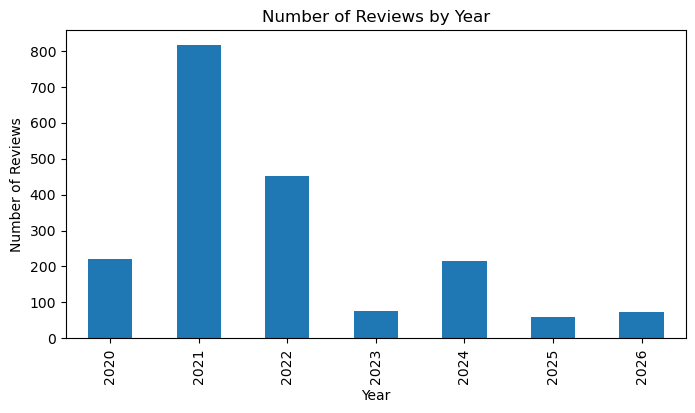

In [59]:
df_clean["year"].value_counts().sort_index().plot(kind="bar", figsize=(8,4))

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

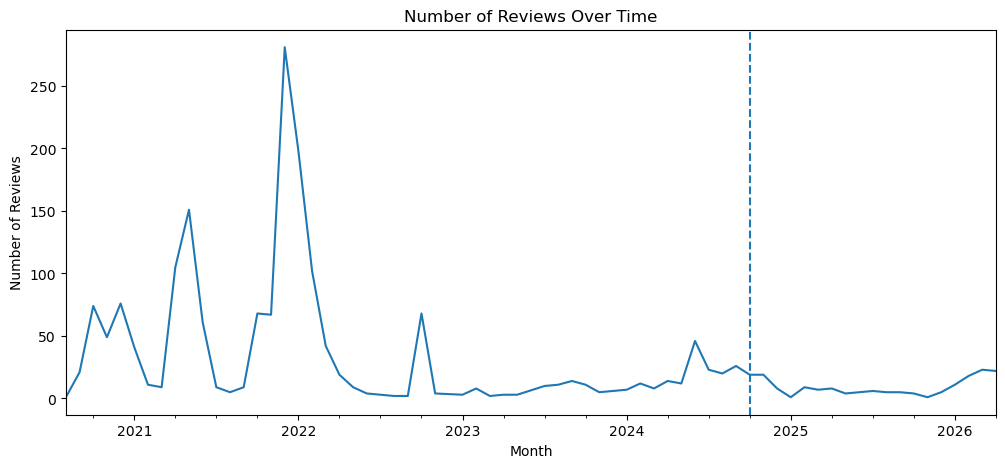

In [60]:
monthly_counts = df_clean.groupby("month").size()

monthly_counts.plot(figsize=(12,5))

plt.axvline(pd.Period("2024-10"), linestyle="--")
plt.title("Number of Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

In [61]:
df_clean["rating"].value_counts().sort_index()

rating
1     286
2      35
3      49
4     102
5    1443
Name: count, dtype: int64

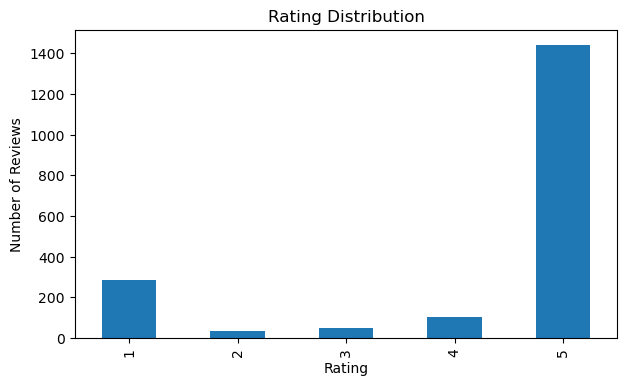

In [62]:
df_clean["rating"].value_counts().sort_index().plot(kind="bar", figsize=(7,4))

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [63]:
df_clean.groupby("post_betsy")["rating"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
post_betsy,,,,
0,1746,4.280641,5.0,1.433629
1,169,3.857988,5.0,1.687827


In [64]:
df_clean["period"] = np.where(df_clean["post_betsy"] == 1, "Post-Betsy", "Pre-Betsy")

df_clean.groupby("period")["rating"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
period,,,,
Post-Betsy,169,3.857988,5.0,1.687827
Pre-Betsy,1746,4.280641,5.0,1.433629


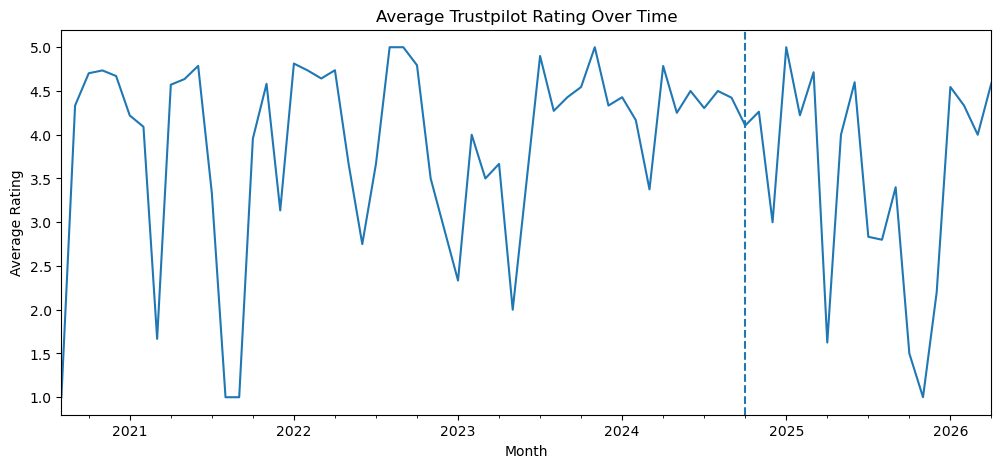

In [65]:
monthly_rating = df_clean.groupby("month")["rating"].mean()

monthly_rating.plot(figsize=(12,5))

plt.axvline(pd.Period("2024-10"), linestyle="--")
plt.title("Average Trustpilot Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.show()

In [72]:
import sys
!{sys.executable} -m pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [73]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [74]:
analyzer = SentimentIntensityAnalyzer()

df_clean["sentiment"] = df_clean["review_text"].apply(
    lambda text: analyzer.polarity_scores(str(text))["compound"]
)

In [75]:
df_clean[["review_text", "rating", "sentiment"]].head()

,review_text,rating,sentiment
0,The whole team was exceptionally helpful and w...,5,0.4754
1,Loan originator and loan coordinator made the ...,5,0.8399
2,John and Sonia made my experience outstanding....,5,0.7269
3,"Irene Lee (my loan officer) was professional, ...",5,0.9106
4,Richard came to my nursery today to help with ...,5,0.8614


In [76]:
df_clean["sentiment"].describe()

count    1915.000000
mean        0.630483
std         0.506131
min        -0.984400
25%         0.589850
50%         0.862500
75%         0.945050
max         0.998200
Name: sentiment, dtype: float64

In [77]:
df_clean.groupby("period")["sentiment"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
period,,,,
Post-Betsy,169,0.515134,0.7345,0.567063
Pre-Betsy,1746,0.641648,0.8689,0.498605


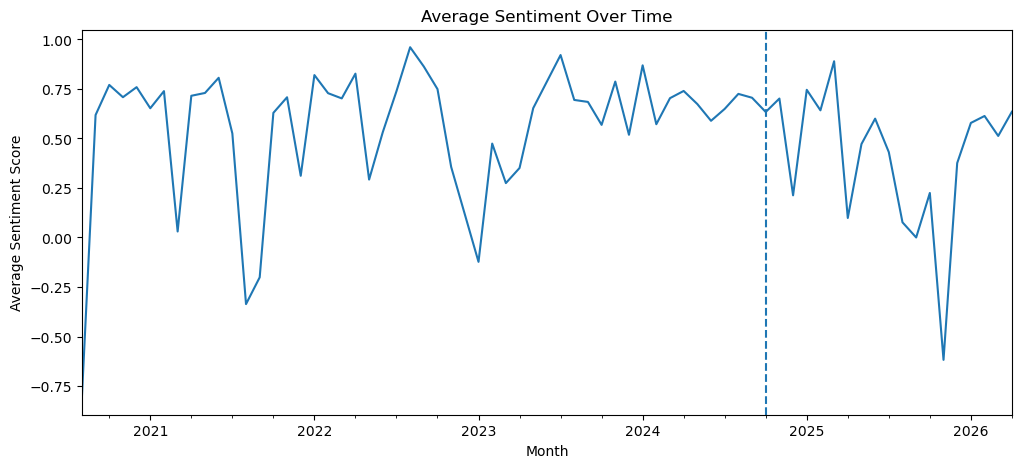

In [78]:
monthly_sentiment = df_clean.groupby("month")["sentiment"].mean()

monthly_sentiment.plot(figsize=(12,5))

plt.axvline(pd.Period("2024-10"), linestyle="--")
plt.title("Average Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.show()

In [80]:
from scipy.stats import ttest_ind

In [81]:
pre_rating = df_clean[df_clean["post_betsy"] == 0]["rating"]
post_rating = df_clean[df_clean["post_betsy"] == 1]["rating"]

ttest_ind(pre_rating, post_rating, equal_var=False)

TtestResult(statistic=np.float64(3.147325709706338), pvalue=np.float64(0.0019102430899727435), df=np.float64(192.19290397273588))

In [82]:
pre_sentiment = df_clean[df_clean["post_betsy"] == 0]["sentiment"]
post_sentiment = df_clean[df_clean["post_betsy"] == 1]["sentiment"]

ttest_ind(pre_sentiment, post_sentiment, equal_var=False)

TtestResult(statistic=np.float64(2.7975666047487087), pvalue=np.float64(0.005668011757663053), df=np.float64(193.98009605691783))

In [83]:
df_clean.to_csv("better_trustpilot_clean.csv", index=False)